In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv(r"C:\Users\Mr.Zabit\Documents\ml_projects\Future_ML_Projects\Future_ML_01_Sales_Forecasting\data\raw\Superstore.csv", encoding='latin-1')
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [15]:
# Checking for duplicate rows and removing them 
df.duplicated().sum()

np.int64(0)

In [16]:
# removing unnecessary columns
cols_to_drop = ['Row ID', 'Order ID','Customer ID', 'Customer Name','Postal Code','Product ID','Product Name','Sub-Category', 'Country', 'State', 'City']
df.drop(columns=cols_to_drop, inplace=True)

In [17]:
df.head()

,Order Date,Ship Date,Ship Mode,Segment,Region,Category,Sales,Quantity,Discount,Profit
0,11/8/2016,11/11/2016,Second Class,Consumer,South,Furniture,261.9600,2,0.00,41.9136
1,11/8/2016,11/11/2016,Second Class,Consumer,South,Furniture,731.9400,3,0.00,219.5820
2,6/12/2016,6/16/2016,Second Class,Corporate,West,Office Supplies,14.6200,2,0.00,6.8714
3,10/11/2015,10/18/2015,Standard Class,Consumer,South,Furniture,957.5775,5,0.45,-383.0310
4,10/11/2015,10/18/2015,Standard Class,Consumer,South,Office Supplies,22.3680,2,0.20,2.5164


In [18]:
# Converting to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [19]:
# reating monthly sales aggregation
df['Month_Order'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month_Order')['Sales'].sum().reset_index()

# convert to time satmp
monthly_sales['Month_Order'] = monthly_sales['Month_Order'].dt.to_timestamp()

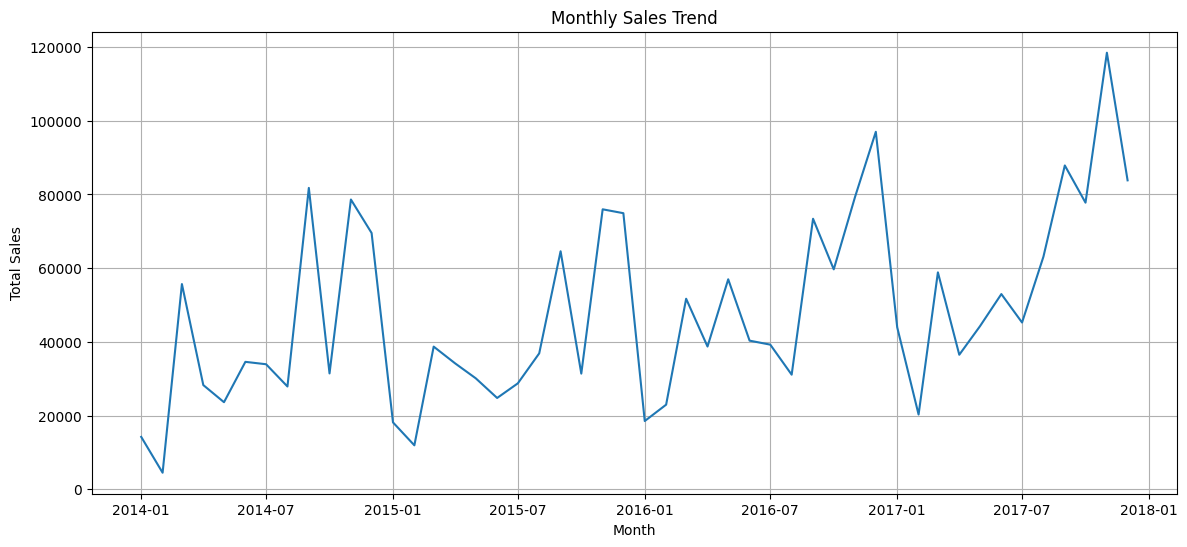

In [20]:
plt.figure(figsize=(14,6))
sns.lineplot(data=monthly_sales, x="Month_Order", y="Sales")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

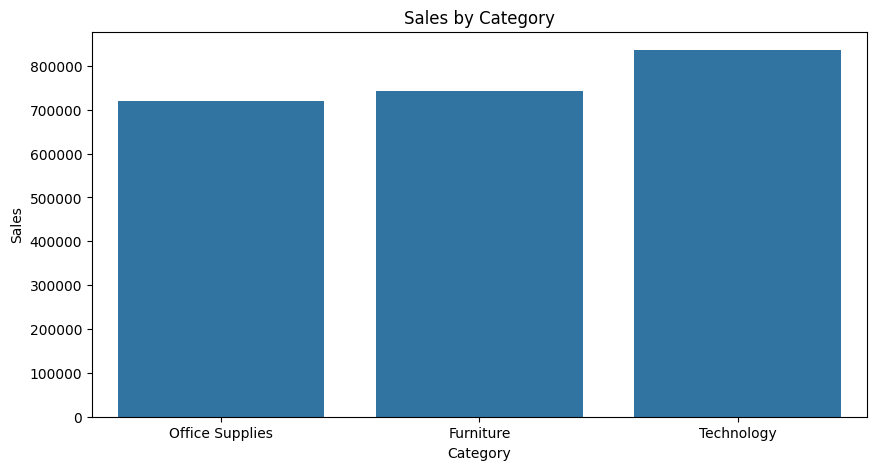

In [21]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values()

plt.figure(figsize=(10,5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

In [22]:
df['Region'].nunique()

4

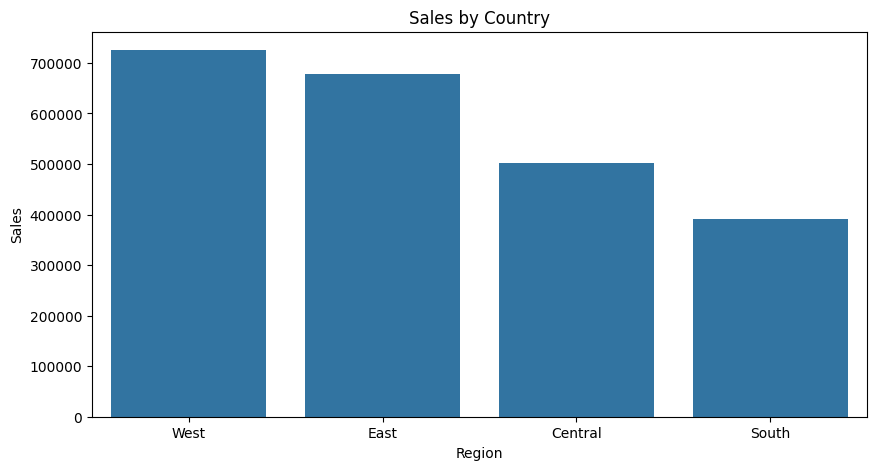

In [23]:
country_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=country_sales.index, y=country_sales.values)
plt.title("Sales by Country")
plt.ylabel("Sales")
plt.show()

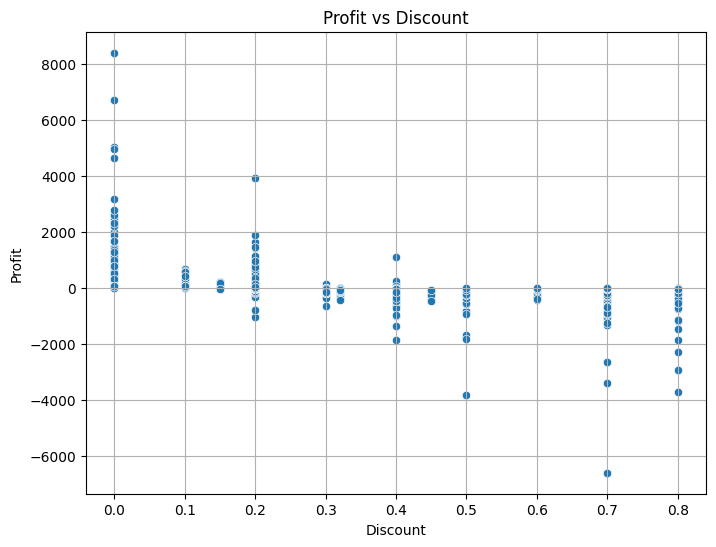

In [24]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Discount", y="Profit")
plt.title("Profit vs Discount")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid(True)
plt.show()